# FSNet 运动去模糊 —— 一体化 Notebook

本 notebook 把 FSNet(T-PAMI) 运动去模糊的 **模型定义 / 训练 / 推理 / 对比图** 全部合并到一个文件，
源码取自官方仓库 `Motion_deblurring/`，已做好以下适配（保证在 **CPU-only Windows** 上跑出和命令行一致的效果）：

1. 合并到单一命名空间时，把数据增强里 `torchvision` 的 `functional`(原别名 `F`) 改名为 `TF`，避免覆盖模型用的 `torch.nn.functional`(`F`)；
2. 加载权重用 `map_location='cpu'`（权重是 GPU 存的，CPU 机器必须）；
3. 内嵌了 `GradualWarmupScheduler`，**无需**再 `pip install warmup_scheduler`；
4. `tensorboard` 改为可选，没装也能训练。

**用法**：在 `work/` 目录下启动 Jupyter，从上到下依次运行即可。
- 已随附 8 张快速验证集 `GOPRO_mini`，开箱即出结果（约 2~3 分钟）。
- 想跑全量 1111 张：把完整的 `GOPRO` 文件夹移到 `work/` 下，并把配置区的 `DATASET` 改成 `"GOPRO"`。
- 想训练：需要 `GOPRO/train/{blur,sharp}` 数据，CPU 上极慢，建议有 GPU 再开。


## 1. 配置区（按需修改这里）

In [ ]:
import os
from pathlib import Path
from types import SimpleNamespace
import torch

# 本 notebook 运行目录（请在 work 文件夹里启动 Jupyter）
WORK_DIR = Path.cwd()

# 数据集: 包含 valid/blur 和 valid/sharp 的【外层】文件夹名
DATASET = "GOPRO"          # ← 跑全量改成 "GOPRO"
DATA_DIR = WORK_DIR / DATASET

MODEL_PATH  = WORK_DIR / "gopro.pkl"            # (可选)预训练权重, 仅在没有训练产物时作回退
RESULT_DIR  = WORK_DIR / "results" / "test"        # 恢复图输出
COMPARE_DIR = WORK_DIR / "results" / "comparison"  # 对比图输出
RESULT_DIR.mkdir(parents=True, exist_ok=True)
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("工作目录:", WORK_DIR)
print("数据集  :", DATA_DIR, "(存在)" if DATA_DIR.exists() else "(!! 不存在, 请把数据移进来)")
print("回退权重:", MODEL_PATH, "(存在)" if MODEL_PATH.exists() else "(不存在, 将改用训练得到的权重)")
print("设备    :", device, "| CUDA 可用:", torch.cuda.is_available())

# 等价于原仓库 argparse 的参数对象, 供 训练/推理/验证 函数使用
args = SimpleNamespace(
    data_dir=str(DATA_DIR),
    test_model=str(MODEL_PATH),
    save_image=True,
    result_dir=str(RESULT_DIR),
    model_save_dir=str(WORK_DIR / "results" / "FSNet_GoPro"),
    batch_size=2,
    learning_rate=1e-4,
    weight_decay=0,
    num_epoch=3000,
    print_freq=100,
    num_worker=0,        # Windows 下设 0 最稳
    save_freq=100,
    valid_freq=100,
    resume='',
)
os.makedirs(args.model_save_dir, exist_ok=True)

工作目录: c:\Users\26846\Desktop\深度学习\大作业\work
数据集  : c:\Users\26846\Desktop\深度学习\大作业\work\GOPRO_mini (存在)
权重    : c:\Users\26846\Desktop\深度学习\大作业\work\gopro.pkl (存在)
设备    : cpu | CUDA 可用: False


## 1.1 可视化全局样式（马卡龙配色）

下面统一加载 `math.yaml`（seaborn-v0_8 风格）与随附的 `makaron.pkl` 马卡龙渐变色图，之后所有图表都复用 `MK` 色图与 `mk(0~1)` 取色函数，保证整份报告风格一致。

In [ ]:
# ========== 可视化全局样式：马卡龙配色 ==========
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1) 应用 math.yaml 全局风格（基于 seaborn-v0_8）
try:
    plt.style.use(str(WORK_DIR / "math.yaml"))
except Exception as e:
    print("[警告] math.yaml 未能应用：", e)

# math.yaml 的 figure.dpi=400 仅适合存图，屏幕内联显示降到 120，避免 1280x720 图过大
matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["savefig.dpi"] = 200

# 2) 马卡龙 colormap：优先读取随附的 makaron.pkl，失败则用内置色表
def get_makaron_cmap(register=True):
    clist = [
        [0.30588235, 0.39607843, 0.60784314],
        [0.54117647, 0.54901961, 0.74901961],
        [0.72156863, 0.65882353, 0.81176471],
        [0.90588235, 0.73725490, 0.77647059],
        [0.99215686, 0.81176471, 0.61960784],
        [0.93725490, 0.64313725, 0.51764706],
        [0.71372549, 0.46274510, 0.42352941],
    ]
    cmap = LinearSegmentedColormap.from_list("makaron", clist)
    if register:
        try:
            matplotlib.colormaps.register(cmap=cmap, name="makaron")
        except Exception:
            pass
    return cmap

try:
    MK = pickle.load(open(WORK_DIR / "makaron.pkl", "rb"))
    try:
        matplotlib.colormaps.register(cmap=MK, name="makaron")
    except Exception:
        pass
except Exception:
    MK = get_makaron_cmap()

# 便捷取色：mk(0.0~1.0) 在马卡龙渐变上取一种颜色
def mk(v):
    return MK(float(np.clip(v, 0.0, 1.0)))

# 一组离散马卡龙色（柱状图 / 多曲线循环用）
MK_COLORS = [mk(0.10), mk(0.28), mk(0.46), mk(0.64), mk(0.82), mk(0.97)]

# 可视化输出目录
VIZ_DIR = WORK_DIR / "results" / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("马卡龙配色就绪 ✓  colormap 名称='makaron'，取色函数 mk(0~1)，图片输出目录:", VIZ_DIR)

## 2. 模型定义
### 2.1 基础层 layers

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
train_size = (1,3,256,256)

class AvgPool2d(nn.Module):
    def __init__(self, kernel_size=None, base_size=None, auto_pad=True, fast_imp=False):
        super().__init__()
        self.kernel_size = kernel_size
        self.base_size = base_size
        self.auto_pad = auto_pad

        # only used for fast implementation
        self.fast_imp = fast_imp
        self.rs = [5,4,3,2,1]
        self.max_r1 = self.rs[0]
        self.max_r2 = self.rs[0]
    def extra_repr(self) -> str:
        return 'kernel_size={}, base_size={}, stride={}, fast_imp={}'.format(
            self.kernel_size, self.base_size, self.kernel_size, self.fast_imp
        )
           
    def forward(self, x):
        if self.kernel_size is None and self.base_size:
            if isinstance(self.base_size, int):
                self.base_size = (self.base_size, self.base_size)
            self.kernel_size = list(self.base_size)
            self.kernel_size[0] = x.shape[2]*self.base_size[0]//train_size[-2]
            self.kernel_size[1] = x.shape[3]*self.base_size[1]//train_size[-1]
            
            # only used for fast implementation
            self.max_r1 = max(1, self.rs[0]*x.shape[2]//train_size[-2])
            self.max_r2 = max(1, self.rs[0]*x.shape[3]//train_size[-1])

        if self.fast_imp:   # Non-equivalent implementation but faster
            h, w = x.shape[2:]
            if self.kernel_size[0]>=h and self.kernel_size[1]>=w:
                out = F.adaptive_avg_pool2d(x,1)
            else:
                r1 = [r for r in self.rs if h%r==0][0]
                r2 = [r for r in self.rs if w%r==0][0]
                # reduction_constraint
                r1 = min(self.max_r1, r1)
                r2 = min(self.max_r2, r2)
                s = x[:,:,::r1, ::r2].cumsum(dim=-1).cumsum(dim=-2)
                n, c, h, w = s.shape
                k1, k2 = min(h-1, self.kernel_size[0]//r1), min(w-1, self.kernel_size[1]//r2)
                out = (s[:,:,:-k1,:-k2]-s[:,:,:-k1,k2:]-s[:,:,k1:,:-k2]+s[:,:,k1:,k2:])/(k1*k2)
                out = torch.nn.functional.interpolate(out, scale_factor=(r1,r2))
        else:
            n, c, h, w = x.shape
            s = x.cumsum(dim=-1).cumsum(dim=-2)
            s = torch.nn.functional.pad(s, (1,0,1,0)) # pad 0 for convenience
            k1, k2 = min(h, self.kernel_size[0]), min(w, self.kernel_size[1])

            s1, s2, s3, s4 = s[:,:,:-k1,:-k2],s[:,:,:-k1,k2:], s[:,:,k1:,:-k2], s[:,:,k1:,k2:]
            out = s4+s1-s2-s3
            out = out / (k1*k2)
    
        if self.auto_pad:
            n, c, h, w = x.shape
            _h, _w = out.shape[2:]
            pad2d = ((w - _w)//2, (w - _w + 1)//2, (h - _h) // 2, (h - _h + 1) // 2)
            out = torch.nn.functional.pad(out, pad2d, mode='replicate')
        
        return out
    
class BasicConv(nn.Module):
    def __init__(self, in_channel, out_channel, kernel_size, stride, bias=True, norm=False, relu=True, transpose=False):
        super(BasicConv, self).__init__()
        if bias and norm:
            bias = False

        padding = kernel_size // 2
        layers = list()
        if transpose:
            padding = kernel_size // 2 -1
            layers.append(nn.ConvTranspose2d(in_channel, out_channel, kernel_size, padding=padding, stride=stride, bias=bias))
        else:
            layers.append(
                nn.Conv2d(in_channel, out_channel, kernel_size, padding=padding, stride=stride, bias=bias))
        if norm:
            layers.append(nn.BatchNorm2d(out_channel))
        if relu:
            layers.append(nn.GELU())
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        return self.main(x)


class Gap(nn.Module):
    def __init__(self, in_channel) -> None:
        super().__init__()

        self.fscale_d = nn.Parameter(torch.zeros(in_channel), requires_grad=True)
        self.fscale_h = nn.Parameter(torch.zeros(in_channel), requires_grad=True)
        # self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.gap = AvgPool2d(base_size=80)

    def forward(self, x):
        x_d = self.gap(x)
        x_h = (x - x_d) * (self.fscale_h[None, :, None, None] + 1.)
        x_d = x_d  * self.fscale_d[None, :, None, None]
        return x_d + x_h


class ResBlock(nn.Module):
    def __init__(self, in_channel, out_channel, filter=False):
        super(ResBlock, self).__init__()
        self.conv1 = BasicConv(in_channel, out_channel, kernel_size=3, stride=1, relu=True)
        self.conv2 = BasicConv(out_channel, out_channel, kernel_size=3, stride=1, relu=False)
        self.filter = filter

        self.dyna = dynamic_filter(in_channel//2) if filter else nn.Identity()
        self.dyna_2 = dynamic_filter(in_channel//2, kernel_size=5) if filter else nn.Identity()

        self.localap = Patch_ap(in_channel//2, patch_size=2)
        self.global_ap = Gap(in_channel//2)


    def forward(self, x):
        out = self.conv1(x)
       
        if self.filter:

            k3, k5 = torch.chunk(out, 2, dim=1)
            out_k3 = self.dyna(k3)
            out_k5 = self.dyna_2(k5)
            out = torch.cat((out_k3, out_k5), dim=1)
            
        non_local, local = torch.chunk(out, 2, dim=1)
        non_local = self.global_ap(non_local)
        local = self.localap(local)
        out = torch.cat((non_local, local), dim=1)
        out = self.conv2(out)
        return out + x

class Unet(nn.Module):
    def __init__(self, in_channel, out_channel, num_res):
        super().__init__()

        self.layers = nn.ModuleList()
        for i in range(num_res-1):
            self.layers.append(ResBlock(in_channel, out_channel))
        self.layers.append(ResBlock(in_channel, out_channel, filter=True))
        self.down = nn.Conv2d(in_channel, in_channel, kernel_size=2, stride=2, groups=in_channel)
        self.num_res = num_res

        self.conv = nn.Conv2d(in_channel*2, in_channel, kernel_size=1, stride=1)
    def forward(self, x):
        res = x.clone()

        for i, layer in enumerate(self.layers):
            if i == self.num_res//4:
                skip = x
                x = self.down(x)
            if i == self.num_res - self.num_res//4:
                x = F.upsample(x, res.shape[2:], mode='bilinear')
                x = self.conv(torch.cat((x, skip), dim=1))
            x = layer(x)

        return x + res

class dynamic_filter(nn.Module):
    def __init__(self, inchannels, kernel_size=3, stride=1, group=8):
        super(dynamic_filter, self).__init__()
        self.stride = stride
        self.kernel_size = kernel_size
        self.group = group

        self.conv = nn.Conv2d(inchannels, group*kernel_size**2, kernel_size=1, stride=1, bias=False)
        self.bn = nn.BatchNorm2d(group*kernel_size**2)
        self.act = nn.Softmax(dim=-2)
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')
        self.lamb_l = nn.Parameter(torch.zeros(inchannels), requires_grad=True)
        self.lamb_h = nn.Parameter(torch.zeros(inchannels), requires_grad=True)
        self.pad = nn.ReflectionPad2d(kernel_size//2)

        self.ap = nn.AdaptiveAvgPool2d((1, 1))
        self.modulate = SFconv(inchannels)

    def forward(self, x):
        identity_input = x # 3,32,64,64
        low_filter = self.ap(x)
        low_filter = self.conv(low_filter)
        low_filter = self.bn(low_filter)     

        n, c, h, w = x.shape  
        x = F.unfold(self.pad(x), kernel_size=self.kernel_size).reshape(n, self.group, c//self.group, self.kernel_size**2, h*w)

        n,c1,p,q = low_filter.shape
        low_filter = low_filter.reshape(n, c1//self.kernel_size**2, self.kernel_size**2, p*q).unsqueeze(2)
       
        low_filter = self.act(low_filter)
    
        low_part = torch.sum(x * low_filter, dim=3).reshape(n, c, h, w)
        out_high = identity_input - low_part
        out = self.modulate(low_part, out_high)
        return out


class SFconv(nn.Module):
    def __init__(self, features, M=2, r=2, L=32) -> None:
        super().__init__()
        
        d = max(int(features/r), L)
        self.features = features

        self.fc = nn.Conv2d(features, d, 1, 1, 0)
        self.fcs = nn.ModuleList([])
        for i in range(M):
            self.fcs.append(
                nn.Conv2d(d, features, 1, 1, 0)
            )
        self.softmax = nn.Softmax(dim=1)
        # self.gap = nn.AdaptiveAvgPool2d(1)
        self.gap = AvgPool2d(base_size=80)

        self.out = nn.Conv2d(features, features, 1, 1, 0)
        
    def forward(self, low, high):
        emerge = low + high
        emerge = self.gap(emerge)

        fea_z = self.fc(emerge)

        high_att = self.fcs[0](fea_z)
        low_att = self.fcs[1](fea_z)
        
        attention_vectors = torch.cat([high_att, low_att], dim=1)

        attention_vectors = self.softmax(attention_vectors)
        high_att, low_att = torch.chunk(attention_vectors, 2, dim=1)

        fea_high = high * high_att
        fea_low = low * low_att
        
        out = self.out(fea_high + fea_low) 
        return out

class Patch_ap(nn.Module):
    def __init__(self, inchannel, patch_size):
        super(Patch_ap, self).__init__()

        # self.ap = nn.AdaptiveAvgPool2d((1,1))
        self.ap = AvgPool2d(base_size=80)

        self.patch_size = patch_size
        self.channel = inchannel * patch_size**2
        self.h = nn.Parameter(torch.zeros(self.channel))
        self.l = nn.Parameter(torch.zeros(self.channel))

    def forward(self, x):

        patch_x = rearrange(x, 'b c (p1 w1) (p2 w2) -> b c p1 w1 p2 w2', p1=self.patch_size, p2=self.patch_size)
        patch_x = rearrange(patch_x, ' b c p1 w1 p2 w2 -> b (c p1 p2) w1 w2', p1=self.patch_size, p2=self.patch_size)

        low = self.ap(patch_x)
        high = (patch_x - low) * self.h[None, :, None, None]
        out = high + low * self.l[None, :, None, None]
        out = rearrange(out, 'b (c p1 p2) w1 w2 -> b c (p1 w1) (p2 w2)', p1=self.patch_size, p2=self.patch_size)

        return out


### 2.2 FSNet 网络结构

In [15]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class EBlock(nn.Module):
    def __init__(self, out_channel, num_res=8):
        super(EBlock, self).__init__()

        layers = [ResBlock(out_channel, out_channel) for _ in range(num_res-1)]
        layers.append(ResBlock(out_channel, out_channel, filter=True))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


class DBlock(nn.Module):
    def __init__(self, channel, num_res=8):
        super(DBlock, self).__init__()

        layers = [ResBlock(channel, channel) for _ in range(num_res-1)]
        layers.append(ResBlock(channel, channel, filter=True))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)
    
class EBlock1(nn.Module):
    def __init__(self, out_channel, num_res=8):
        super(EBlock1, self).__init__()

        self.layers = Unet(out_channel, out_channel, num_res)
    def forward(self, x):
        return self.layers(x)


class DBlock1(nn.Module):
    def __init__(self, channel, num_res=8):
        super(DBlock1, self).__init__()

        self.layers = Unet(channel, channel, num_res)
    def forward(self, x):
        return self.layers(x)

class SCM(nn.Module):
    def __init__(self, out_plane):
        super(SCM, self).__init__()
        self.main = nn.Sequential(
            BasicConv(3, out_plane//4, kernel_size=3, stride=1, relu=True),
            BasicConv(out_plane // 4, out_plane // 2, kernel_size=1, stride=1, relu=True),
            BasicConv(out_plane // 2, out_plane // 2, kernel_size=3, stride=1, relu=True),
            BasicConv(out_plane // 2, out_plane, kernel_size=1, stride=1, relu=False),
            nn.InstanceNorm2d(out_plane, affine=True)
        )

    def forward(self, x):
        x = self.main(x)
        return x


class FAM(nn.Module):
    def __init__(self, channel):
        super(FAM, self).__init__()
        self.merge = BasicConv(channel*2, channel, kernel_size=3, stride=1, relu=False)

    def forward(self, x1, x2):
        return self.merge(torch.cat([x1, x2], dim=1))

class FSNet(nn.Module):
    def __init__(self, num_res=16):
        super(FSNet, self).__init__()

        base_channel = 32

        self.Encoder = nn.ModuleList([
            EBlock1(base_channel, num_res),
            EBlock(base_channel*2, num_res),
            EBlock(base_channel*4, num_res),
        ])

        self.feat_extract = nn.ModuleList([
            BasicConv(3, base_channel, kernel_size=3, relu=True, stride=1),
            BasicConv(base_channel, base_channel*2, kernel_size=3, relu=True, stride=2),
            BasicConv(base_channel*2, base_channel*4, kernel_size=3, relu=True, stride=2),
            BasicConv(base_channel*4, base_channel*2, kernel_size=4, relu=True, stride=2, transpose=True),
            BasicConv(base_channel*2, base_channel, kernel_size=4, relu=True, stride=2, transpose=True),
            BasicConv(base_channel, 3, kernel_size=3, relu=False, stride=1)
        ])

        self.Decoder = nn.ModuleList([
            DBlock(base_channel * 4, num_res),
            DBlock(base_channel * 2, num_res),
            DBlock1(base_channel, num_res)
        ])

        self.Convs = nn.ModuleList([
            BasicConv(base_channel * 4, base_channel * 2, kernel_size=1, relu=True, stride=1),
            BasicConv(base_channel * 2, base_channel, kernel_size=1, relu=True, stride=1),
        ])

        self.ConvsOut = nn.ModuleList(
            [
                BasicConv(base_channel * 4, 3, kernel_size=3, relu=False, stride=1),
                BasicConv(base_channel * 2, 3, kernel_size=3, relu=False, stride=1),
            ]
        )

        self.FAM1 = FAM(base_channel * 4)
        self.SCM1 = SCM(base_channel * 4)
        self.FAM2 = FAM(base_channel * 2)
        self.SCM2 = SCM(base_channel * 2)

    def forward(self, x):
        x_2 = F.interpolate(x, scale_factor=0.5)
        x_4 = F.interpolate(x_2, scale_factor=0.5)
        z2 = self.SCM2(x_2)
        z4 = self.SCM1(x_4)

        outputs = list()
        # 256
        x_ = self.feat_extract[0](x)
        res1 = self.Encoder[0](x_)
        # 128
        z = self.feat_extract[1](res1)
        z = self.FAM2(z, z2)
        res2 = self.Encoder[1](z)
        # 64
        z = self.feat_extract[2](res2)
        z = self.FAM1(z, z4)
        z = self.Encoder[2](z)

        z = self.Decoder[0](z)
        z_ = self.ConvsOut[0](z)
        # 128
        z = self.feat_extract[3](z)
        outputs.append(z_+x_4)

        z = torch.cat([z, res2], dim=1)
        z = self.Convs[0](z)
        z = self.Decoder[1](z)
        z_ = self.ConvsOut[1](z)
        # 256
        z = self.feat_extract[4](z)
        outputs.append(z_+x_2)

        z = torch.cat([z, res1], dim=1)
        z = self.Convs[1](z)
        z = self.Decoder[2](z)
        z = self.feat_extract[5](z)
        outputs.append(z+x)

        return outputs


def build_net():
    return FSNet()

## 3. 数据管线
### 3.1 成对数据增强

In [16]:
import random
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


class PairRandomCrop(transforms.RandomCrop):

    def __call__(self, image, label):

        if self.padding is not None:
            image = TF.pad(image, self.padding, self.fill, self.padding_mode)
            label = TF.pad(label, self.padding, self.fill, self.padding_mode)

        # pad the width if needed
        if self.pad_if_needed and image.size[0] < self.size[1]:
            image = TF.pad(image, (self.size[1] - image.size[0], 0), self.fill, self.padding_mode)
            label = TF.pad(label, (self.size[1] - label.size[0], 0), self.fill, self.padding_mode)
        # pad the height if needed
        if self.pad_if_needed and image.size[1] < self.size[0]:
            image = TF.pad(image, (0, self.size[0] - image.size[1]), self.fill, self.padding_mode)
            label = TF.pad(label, (0, self.size[0] - image.size[1]), self.fill, self.padding_mode)

        i, j, h, w = self.get_params(image, self.size)

        return TF.crop(image, i, j, h, w), TF.crop(label, i, j, h, w)


class PairCompose(transforms.Compose):
    def __call__(self, image, label):
        for t in self.transforms:
            image, label = t(image, label)
        return image, label


class PairRandomHorizontalFilp(transforms.RandomHorizontalFlip):
    def __call__(self, img, label):
        """
        Args:
            img (PIL Image): Image to be flipped.

        Returns:
            PIL Image: Randomly flipped image.
        """
        if random.random() < self.p:
            return TF.hflip(img), TF.hflip(label)
        return img, label


class PairToTensor(transforms.ToTensor):
    def __call__(self, pic, label):
        """
        Args:
            pic (PIL Image or numpy.ndarray): Image to be converted to tensor.

        Returns:
            Tensor: Converted image.
        """
        return TF.to_tensor(pic), TF.to_tensor(label)


### 3.2 数据集与 DataLoader
测试集结构需为 `data_dir/valid/blur` + `data_dir/valid/sharp`（同名成对）。

In [17]:
import os
from PIL import Image as Image
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset, DataLoader


def train_dataloader(path, batch_size=64, num_workers=0, use_transform=True):
    image_dir = os.path.join(path, 'train')

    transform = None
    if use_transform:
        transform = PairCompose(
            [
                PairRandomCrop(256),
                PairRandomHorizontalFilp(),
                PairToTensor()
            ]
        )
    dataloader = DataLoader(
        DeblurDataset(image_dir, transform=transform),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    return dataloader


def test_dataloader(path, batch_size=1, num_workers=0):
    image_dir = os.path.join(path, 'valid')
    dataloader = DataLoader(
        DeblurDataset(image_dir, is_test=True),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return dataloader


def valid_dataloader(path, batch_size=1, num_workers=0):
    dataloader = DataLoader(
        DeblurDataset(os.path.join(path, 'valid')),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return dataloader


class DeblurDataset(Dataset):
    def __init__(self, image_dir, transform=None, is_test=False):
        self.image_dir = image_dir
        self.image_list = os.listdir(os.path.join(image_dir, 'blur/'))
        self._check_image(self.image_list)
        self.image_list.sort()
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.image_dir, 'blur', self.image_list[idx]))
        label = Image.open(os.path.join(self.image_dir, 'sharp', self.image_list[idx]))

        if self.transform:
            image, label = self.transform(image, label)
        else:
            image = TF.to_tensor(image)
            label = TF.to_tensor(label)
        if self.is_test:
            name = self.image_list[idx]
            return image, label, name
        return image, label

    @staticmethod
    def _check_image(lst):
        for x in lst:
            splits = x.split('.')
            if splits[-1] not in ['png', 'jpg', 'jpeg', 'tif']:
                raise ValueError

## 3.3 数据可视化：模糊 / 清晰 配对与频域分析

- **配对样本**：模糊输入 vs 清晰原图（GT），以及二者的差异强度图（差异越大说明该处运动模糊越严重）。
- **频域分析**：呼应 FSNet「频率选择（Frequency Selection）」的核心思想——运动模糊会显著衰减图像高频，这里用二维 FFT 对数频谱与径向能量曲线，直观展示模糊图相对清晰图的高频损失。

In [ ]:
# ========== 数据可视化①：模糊 / 清晰 / 差异 配对样本 ==========
from PIL import Image

_blur_dir = DATA_DIR / "valid" / "blur"
_sharp_dir = DATA_DIR / "valid" / "sharp"
_names = sorted(p.name for p in _blur_dir.glob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg"))
_show = _names[:3]

n = len(_show)
fig, axes = plt.subplots(n, 3, figsize=(14, 3.1 * n))
axes = np.atleast_2d(axes)
for r, name in enumerate(_show):
    blur = np.asarray(Image.open(_blur_dir / name).convert("RGB"))
    sharp = np.asarray(Image.open(_sharp_dir / name).convert("RGB"))
    diff = np.abs(blur.astype(np.float32) - sharp.astype(np.float32)).mean(axis=2)

    axes[r, 0].imshow(blur);  axes[r, 0].set_title("模糊输入 Blurred", fontsize=12)
    axes[r, 1].imshow(sharp); axes[r, 1].set_title("清晰原图 Sharp (GT)", fontsize=12)
    im = axes[r, 2].imshow(diff, cmap="makaron")
    axes[r, 2].set_title("差异强度 |Blur-Sharp| (均值 %.1f)" % diff.mean(), fontsize=12)
    fig.colorbar(im, ax=axes[r, 2], fraction=0.046, pad=0.04)
    for c in range(3):
        axes[r, c].axis("off")

fig.suptitle("GOPRO 验证集：模糊 / 清晰 配对样本与差异强度图", fontsize=15, y=1.005)
plt.tight_layout()
plt.savefig(VIZ_DIR / "01_dataset_pairs.png", bbox_inches="tight")
plt.show()
print("已保存：", VIZ_DIR / "01_dataset_pairs.png")

In [ ]:
# ========== 数据可视化②：数据集规模 + 频域(FFT)分析 ==========
def _count(p):
    return len(list(Path(p).glob("*"))) if Path(p).is_dir() else 0

splits = {
    "train/blur": DATA_DIR / "train" / "blur",
    "train/sharp": DATA_DIR / "train" / "sharp",
    "valid/blur": DATA_DIR / "valid" / "blur",
    "valid/sharp": DATA_DIR / "valid" / "sharp",
}
counts = {k: _count(v) for k, v in splits.items()}

def to_gray(arr):
    return np.asarray(arr, np.float32) @ np.array([0.299, 0.587, 0.114], np.float32)

def log_spectrum(gray):
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray))))

def radial_profile(spec):
    h, w = spec.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.indices((h, w))
    r = np.hypot(xx - cx, yy - cy).astype(int)
    tbin = np.bincount(r.ravel(), spec.ravel())
    nr = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)

# 取一张样本做频域对比
_name0 = _show[0]
g_blur = to_gray(Image.open(_blur_dir / _name0).convert("RGB"))
g_sharp = to_gray(Image.open(_sharp_dir / _name0).convert("RGB"))
sp_blur, sp_sharp = log_spectrum(g_blur), log_spectrum(g_sharp)
rp_blur, rp_sharp = radial_profile(sp_blur), radial_profile(sp_sharp)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) 数据集规模
bar_colors = [mk(0.15), mk(0.32), mk(0.62), mk(0.82)]
bars = axes[0].bar(range(len(counts)), list(counts.values()),
                   color=bar_colors, edgecolor="white", linewidth=1.2)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(list(counts.keys()), rotation=20, ha="right")
axes[0].set_ylabel("图像数量")
axes[0].set_title("数据集规模（成对图像数）")
for b, v in zip(bars, counts.values()):
    axes[0].text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom", fontsize=10)

# (b) 模糊图 FFT 对数频谱
im = axes[1].imshow(sp_blur, cmap="makaron")
axes[1].set_title("模糊图 FFT 对数频谱（中心=低频）")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# (c) 径向能量曲线：模糊 vs 清晰
freq = np.linspace(0, 1, len(rp_blur))
axes[2].plot(freq, rp_blur, color=mk(0.85), linewidth=2.2, label="模糊 Blurred")
axes[2].plot(freq, rp_sharp, color=mk(0.16), linewidth=2.2, label="清晰 Sharp")
axes[2].fill_between(freq, rp_blur, rp_sharp, where=(rp_sharp >= rp_blur),
                     color=mk(0.45), alpha=0.25, label="高频损失区")
axes[2].set_xlabel("归一化空间频率（0=低频 → 1=高频）")
axes[2].set_ylabel("平均对数幅值")
axes[2].set_title("径向频谱能量：模糊图高频被抑制")
axes[2].legend()

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_dataset_freq.png", bbox_inches="tight")
plt.show()
print("数据集规模：", counts)

## 4. 工具函数

In [18]:
import time
import numpy as np


class Adder(object):
    def __init__(self):
        self.count = 0
        self.num = float(0)

    def reset(self):
        self.count = 0
        self.num = float(0)

    def __call__(self, num):
        self.count += 1
        self.num += num

    def average(self):
        return self.num / self.count


class Timer(object):
    def __init__(self, option='s'):
        self.tm = 0
        self.option = option
        if option == 's':
            self.devider = 1
        elif option == 'm':
            self.devider = 60
        else:
            self.devider = 3600

    def tic(self):
        self.tm = time.time()

    def toc(self):
        return (time.time() - self.tm) / self.devider


def check_lr(optimizer):
    for i, param_group in enumerate(optimizer.param_groups):
        lr = param_group['lr']
    return lr


## 5. 学习率 warmup 调度器（内嵌, 训练用）

In [19]:
from torch.optim.lr_scheduler import _LRScheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau


class GradualWarmupScheduler(_LRScheduler):
    """ Gradually warm-up(increasing) learning rate in optimizer.
    Proposed in 'Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour'.

    Args:
        optimizer (Optimizer): Wrapped optimizer.
        multiplier: target learning rate = base lr * multiplier if multiplier > 1.0. if multiplier = 1.0, lr starts from 0 and ends up with the base_lr.
        total_epoch: target learning rate is reached at total_epoch, gradually
        after_scheduler: after target_epoch, use this scheduler(eg. ReduceLROnPlateau)
    """

    def __init__(self, optimizer, multiplier, total_epoch, after_scheduler=None):
        self.multiplier = multiplier
        if self.multiplier < 1.:
            raise ValueError('multiplier should be greater thant or equal to 1.')
        self.total_epoch = total_epoch
        self.after_scheduler = after_scheduler
        self.finished = False
        super(GradualWarmupScheduler, self).__init__(optimizer)

    def get_lr(self):
        if self.last_epoch > self.total_epoch:
            if self.after_scheduler:
                if not self.finished:
                    self.after_scheduler.base_lrs = [base_lr * self.multiplier for base_lr in self.base_lrs]
                    self.finished = True
                return self.after_scheduler.get_lr()
            return [base_lr * self.multiplier for base_lr in self.base_lrs]

        if self.multiplier == 1.0:
            return [base_lr * (float(self.last_epoch) / self.total_epoch) for base_lr in self.base_lrs]
        else:
            return [base_lr * ((self.multiplier - 1.) * self.last_epoch / self.total_epoch + 1.) for base_lr in self.base_lrs]

    def step_ReduceLROnPlateau(self, metrics, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
        self.last_epoch = epoch if epoch != 0 else 1  # ReduceLROnPlateau is called at the end of epoch, whereas others are called at beginning
        if self.last_epoch <= self.total_epoch:
            warmup_lr = [base_lr * ((self.multiplier - 1.) * self.last_epoch / self.total_epoch + 1.) for base_lr in self.base_lrs]
            for param_group, lr in zip(self.optimizer.param_groups, warmup_lr):
                param_group['lr'] = lr
        else:
            if epoch is None:
                self.after_scheduler.step(metrics, None)
            else:
                self.after_scheduler.step(metrics, epoch - self.total_epoch)

    def step(self, epoch=None, metrics=None):
        if type(self.after_scheduler) != ReduceLROnPlateau:
            if self.finished and self.after_scheduler:
                if epoch is None:
                    self.after_scheduler.step(None)
                else:
                    self.after_scheduler.step(epoch - self.total_epoch)
            else:
                return super(GradualWarmupScheduler, self).step(epoch)
        else:
            self.step_ReduceLROnPlateau(metrics, epoch)


## 6. 训练代码

> ⚠️ 训练需要 `GOPRO/train/{blur,sharp}` 数据，且在 **CPU 上极慢**（论文用多卡 GPU 训了几千 epoch）。
> 本格默认**不运行**，仅供查阅/有 GPU 时使用。

In [20]:
import torch
import os
from skimage.metrics import peak_signal_noise_ratio
import torch.nn.functional as f

def _valid(model, args, ep):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gopro = valid_dataloader(args.data_dir, batch_size=1, num_workers=0)
    model.eval()
    psnr_adder = Adder()

    with torch.no_grad():
        print('Start GoPro Evaluation')
        factor=8
        for idx, data in enumerate(gopro):
            input_img, label_img = data
            input_img = input_img.to(device)

            h, w = input_img.shape[2], input_img.shape[3]
            H, W = ((h+factor)//factor)*factor, ((w+factor)//factor*factor)
            padh = H-h if h%factor!=0 else 0
            padw = W-w if w%factor!=0 else 0
            input_img = f.pad(input_img, (0, padw, 0, padh), 'reflect')

            if not os.path.exists(os.path.join(args.result_dir, '%d' % (ep))):
                os.mkdir(os.path.join(args.result_dir, '%d' % (ep)))

            pred = model(input_img)[2]
            pred = pred[:,:,:h,:w]

            pred_clip = torch.clamp(pred, 0, 1)
            p_numpy = pred_clip.squeeze(0).cpu().numpy()
            label_numpy = label_img.squeeze(0).cpu().numpy()

            psnr = peak_signal_noise_ratio(p_numpy, label_numpy, data_range=1)

            psnr_adder(psnr)
            print('\r%03d'%idx, end=' ')

    print('\n')
    model.train()
    return psnr_adder.average()

In [ ]:
try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    class SummaryWriter:  # 未装 tensorboard 时的占位, 不影响训练
        def __init__(self, *a, **k): pass
        def add_scalar(self, *a, **k): pass
        def close(self): pass

import os
import json
import torch
import torch.nn.functional as F


def _train(model, args):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    criterion = torch.nn.L1Loss()

    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, betas=(0.9, 0.999), eps=1e-8)
    dataloader = train_dataloader(args.data_dir, args.batch_size, args.num_worker)
    max_iter = len(dataloader)

    warmup_epochs=3
    scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.num_epoch-warmup_epochs, eta_min=1e-6)
    scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=warmup_epochs, after_scheduler=scheduler_cosine)
    scheduler.step()
    epoch = 1
    if args.resume:
        state = torch.load(args.resume)
        epoch = state['epoch']
        optimizer.load_state_dict(state['optimizer'])
        model.load_state_dict(state['model'])
        print('Resume from %d'%epoch)
        epoch += 1

    writer = SummaryWriter()
    epoch_pixel_adder = Adder()
    epoch_fft_adder = Adder()
    iter_pixel_adder = Adder()
    iter_fft_adder = Adder()
    epoch_timer = Timer('m')
    iter_timer = Timer('m')
    best_psnr=-1

    # —— 训练历史记录（供后续可视化使用，每个 epoch 落盘一次）——
    history = {'iter_step': [], 'iter_pixel': [], 'iter_fft': [], 'iter_total': [],
               'epoch': [], 'epoch_pixel': [], 'epoch_fft': [], 'epoch_total': [], 'epoch_lr': [],
               'val_epoch': [], 'val_psnr': []}
    hist_path = os.path.join(args.model_save_dir, 'training_history.json')

    for epoch_idx in range(epoch, args.num_epoch + 1):

        epoch_timer.tic()
        iter_timer.tic()
        for iter_idx, batch_data in enumerate(dataloader):

            input_img, label_img = batch_data
            input_img = input_img.to(device)
            label_img = label_img.to(device)

            optimizer.zero_grad()
            pred_img = model(input_img)
            label_img2 = F.interpolate(label_img, scale_factor=0.5, mode='bilinear')
            label_img4 = F.interpolate(label_img, scale_factor=0.25, mode='bilinear')
            l1 = criterion(pred_img[0], label_img4)
            l2 = criterion(pred_img[1], label_img2)
            l3 = criterion(pred_img[2], label_img)
            loss_content = l1+l2+l3

            label_fft1 = torch.fft.fft2(label_img4, dim=(-2,-1))
            label_fft1 = torch.stack((label_fft1.real, label_fft1.imag), -1)

            pred_fft1 = torch.fft.fft2(pred_img[0], dim=(-2,-1))
            pred_fft1 = torch.stack((pred_fft1.real, pred_fft1.imag), -1)

            label_fft2 = torch.fft.fft2(label_img2, dim=(-2,-1))
            label_fft2 = torch.stack((label_fft2.real, label_fft2.imag), -1)

            pred_fft2 = torch.fft.fft2(pred_img[1], dim=(-2,-1))
            pred_fft2 = torch.stack((pred_fft2.real, pred_fft2.imag), -1)

            label_fft3 = torch.fft.fft2(label_img, dim=(-2,-1))
            label_fft3 = torch.stack((label_fft3.real, label_fft3.imag), -1)

            pred_fft3 = torch.fft.fft2(pred_img[2], dim=(-2,-1))
            pred_fft3 = torch.stack((pred_fft3.real, pred_fft3.imag), -1)

            f1 = criterion(pred_fft1, label_fft1)
            f2 = criterion(pred_fft2, label_fft2)
            f3 = criterion(pred_fft3, label_fft3)
            loss_fft = f1+f2+f3

            loss = loss_content + 0.1 * loss_fft
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.01)
            optimizer.step()

            iter_pixel_adder(loss_content.item())
            iter_fft_adder(loss_fft.item())

            epoch_pixel_adder(loss_content.item())
            epoch_fft_adder(loss_fft.item())

            if (iter_idx + 1) % args.print_freq == 0:
                print("Time: %7.4f Epoch: %03d Iter: %4d/%4d LR: %.10f Loss content: %7.4f Loss fft: %7.4f" % (
                    iter_timer.toc(), epoch_idx, iter_idx + 1, max_iter, scheduler.get_lr()[0], iter_pixel_adder.average(),
                    iter_fft_adder.average()))
                writer.add_scalar('Pixel Loss', iter_pixel_adder.average(), iter_idx + (epoch_idx-1)* max_iter)
                writer.add_scalar('FFT Loss', iter_fft_adder.average(), iter_idx + (epoch_idx - 1) * max_iter)

                # —— 记录 iter 级损失 ——
                _gstep = iter_idx + (epoch_idx - 1) * max_iter
                _pix = iter_pixel_adder.average()
                _fft = iter_fft_adder.average()
                history['iter_step'].append(int(_gstep))
                history['iter_pixel'].append(float(_pix))
                history['iter_fft'].append(float(_fft))
                history['iter_total'].append(float(_pix + 0.1 * _fft))

                iter_timer.tic()
                iter_pixel_adder.reset()
                iter_fft_adder.reset()
        overwrite_name = os.path.join(args.model_save_dir, 'model.pkl')
        torch.save({'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'epoch': epoch_idx}, overwrite_name)

        if epoch_idx % args.save_freq == 0:
            save_name = os.path.join(args.model_save_dir, 'model_%d.pkl' % epoch_idx)
            torch.save({'model': model.state_dict()}, save_name)
        print("EPOCH: %02d\nElapsed time: %4.2f Epoch Pixel Loss: %7.4f Epoch FFT Loss: %7.4f" % (
            epoch_idx, epoch_timer.toc(), epoch_pixel_adder.average(), epoch_fft_adder.average()))

        # —— 记录 epoch 级损失与学习率 ——
        _ep_pix = epoch_pixel_adder.average()
        _ep_fft = epoch_fft_adder.average()
        history['epoch'].append(int(epoch_idx))
        history['epoch_pixel'].append(float(_ep_pix))
        history['epoch_fft'].append(float(_ep_fft))
        history['epoch_total'].append(float(_ep_pix + 0.1 * _ep_fft))
        history['epoch_lr'].append(float(check_lr(optimizer)))

        epoch_fft_adder.reset()
        epoch_pixel_adder.reset()
        scheduler.step()
        if epoch_idx % args.valid_freq == 0:
            val_gopro = _valid(model, args, epoch_idx)
            print('%03d epoch \n Average GOPRO PSNR %.2f dB' % (epoch_idx, val_gopro))
            writer.add_scalar('PSNR_GOPRO', val_gopro, epoch_idx)
            history['val_epoch'].append(int(epoch_idx))
            history['val_psnr'].append(float(val_gopro))
            if val_gopro >= best_psnr:
                best_psnr = val_gopro          # 修正: 记录当前最佳, 仅在提升时另存 Best.pkl
                torch.save({'model': model.state_dict()}, os.path.join(args.model_save_dir, 'Best.pkl'))

        # —— 每个 epoch 落盘一次训练历史, 便于中途可视化 ——
        with open(hist_path, 'w', encoding='utf-8') as _f:
            json.dump(history, _f, ensure_ascii=False, indent=2)
    save_name = os.path.join(args.model_save_dir, 'Final.pkl')
    torch.save({'model': model.state_dict()}, save_name)
    with open(hist_path, 'w', encoding='utf-8') as _f:
        json.dump(history, _f, ensure_ascii=False, indent=2)
    print('训练历史已保存:', hist_path)
    return history

In [ ]:
RUN_TRAINING = True   # ← 改成 True 才会真正开始训练(需 GOPRO/train 数据 + 最好有 GPU)

TRAIN_HISTORY = None
if RUN_TRAINING:
    model = build_net().to(device)
    TRAIN_HISTORY = _train(model, args)   # 返回训练历史(损失/学习率/PSNR), 供下方“训练过程可视化”使用
else:
    print("训练已跳过。需要训练时: 准备好 GOPRO/train 数据 -> 把 RUN_TRAINING 改为 True -> 重跑本格。")

## 6.1 训练过程可视化（损失 / 学习率 / 验证 PSNR）

`_train` 会把训练历史写入 `results/FSNet_GoPro/training_history.json`。下面优先读取该文件绘制 **迭代级损失曲线**、**逐 epoch 损失分量** 与 **验证 PSNR**；学习率调度（warmup + 余弦退火）则直接按配置模拟，即使尚未训练也能展示完整的调度曲线。

In [ ]:
# ========== 训练可视化：损失曲线 / 学习率调度 / 验证 PSNR ==========
import json

# 1) 读取训练历史（若训练过）
_hist = None
if "TRAIN_HISTORY" in globals() and TRAIN_HISTORY:
    _hist = TRAIN_HISTORY
else:
    _hp = os.path.join(args.model_save_dir, "training_history.json")
    if os.path.exists(_hp):
        _hist = json.load(open(_hp, encoding="utf-8"))

# 2) 学习率调度（按配置模拟，与 _train 完全一致，无需训练即可绘制）
def simulate_lr(num_epoch, base_lr, warmup=3):
    dummy = torch.nn.Parameter(torch.zeros(1))
    opt = torch.optim.Adam([dummy], lr=base_lr)
    cos = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epoch - warmup, eta_min=1e-6)
    sch = GradualWarmupScheduler(opt, multiplier=1, total_epoch=warmup, after_scheduler=cos)
    sch.step()
    lrs = []
    for _ in range(1, num_epoch + 1):
        lrs.append(opt.param_groups[0]["lr"])
        sch.step()
    return lrs

lr_curve = simulate_lr(args.num_epoch, args.learning_rate, warmup=3)

def _smooth(y, k=9):
    y = np.asarray(y, dtype=float)
    if len(y) < k or k < 2:
        return None
    return np.convolve(y, np.ones(k) / k, mode="valid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) 迭代级损失曲线
ax = axes[0, 0]
if _hist and _hist["iter_step"]:
    steps = _hist["iter_step"]
    ax.plot(steps, _hist["iter_total"], color=mk(0.85), linewidth=1.4, alpha=0.55, label="总损失(逐打印)")
    sm = _smooth(_hist["iter_total"], 9)
    if sm is not None:
        ax.plot(steps[len(steps) - len(sm):], sm, color=mk(0.12), linewidth=2.4, label="总损失(平滑)")
    ax.set_xlabel("迭代步 Step"); ax.set_ylabel("Loss")
    ax.set_title("训练损失（迭代级）"); ax.legend()
else:
    ax.text(0.5, 0.5, "暂无训练历史\n(完成训练后自动生成)", ha="center", va="center",
            fontsize=13, color=mk(0.2)); ax.set_title("训练损失（迭代级）")

# (b) epoch 级 内容/FFT/总 损失
ax = axes[0, 1]
if _hist and _hist["epoch"]:
    ep = _hist["epoch"]
    ax.plot(ep, _hist["epoch_pixel"], "o-", color=mk(0.18), linewidth=2, markersize=4, label="内容损失 L1")
    ax.plot(ep, _hist["epoch_fft"], "o-", color=mk(0.6), linewidth=2, markersize=4, label="频域损失 FFT")
    ax.plot(ep, _hist["epoch_total"], "o-", color=mk(0.92), linewidth=2, markersize=4, label="总损失")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("各损失分量随 Epoch 变化"); ax.legend()
else:
    ax.text(0.5, 0.5, "暂无训练历史", ha="center", va="center", fontsize=13, color=mk(0.2))
    ax.set_title("各损失分量随 Epoch 变化")

# (c) 学习率调度（始终可绘制）
ax = axes[1, 0]
ax.plot(range(1, len(lr_curve) + 1), lr_curve, color=mk(0.42), linewidth=2.2)
ax.axvspan(0, 3, color=mk(0.85), alpha=0.18, label="Warmup (3 epoch)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate")
ax.set_title("学习率调度：Warmup + 余弦退火 (base=%g)" % args.learning_rate)
ax.legend()

# (d) 验证 PSNR
ax = axes[1, 1]
if _hist and _hist["val_psnr"]:
    ax.plot(_hist["val_epoch"], _hist["val_psnr"], "o-", color=mk(0.15), linewidth=2.2, markersize=6)
    _bi = int(np.argmax(_hist["val_psnr"]))
    _bx, _by = _hist["val_epoch"][_bi], _hist["val_psnr"][_bi]
    ax.scatter([_bx], [_by], s=150, color=mk(0.95), zorder=5, edgecolor="white", linewidth=1.5)
    ax.annotate("最佳 %.2f dB" % _by, (_bx, _by), textcoords="offset points", xytext=(0, 10), ha="center")
    ax.set_xlabel("Epoch"); ax.set_ylabel("PSNR (dB)")
    ax.set_title("验证集 PSNR 变化")
else:
    ax.text(0.5, 0.5, "暂无验证 PSNR 历史", ha="center", va="center", fontsize=13, color=mk(0.2))
    ax.set_title("验证集 PSNR 变化")

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_training_curves.png", bbox_inches="tight")
plt.show()
if _hist is None:
    print("提示：尚未检测到训练历史，仅展示学习率调度曲线。完成训练后重跑本格即可显示损失/PSNR。")

## 7. 推理（加载预训练模型, 跑出 PSNR）

直接复现命令行效果：逐张打印 PSNR、输出平均 PSNR，并把恢复图存到 `results/test/`。
8 张 mini 集在 CPU 上约 2~3 分钟。

In [ ]:
import os
import json
import numpy as np
import torch
import torchvision.transforms.functional as TF
from skimage.metrics import peak_signal_noise_ratio
import torch.nn.functional as f

EVAL_RESULTS = None   # 评估结果(逐张 PSNR), 供下方“推理结果可视化”使用

def _eval(model, args):
    global EVAL_RESULTS
    state_dict = torch.load(args.test_model, map_location='cpu')
    model.load_state_dict(state_dict['model'])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataloader = test_dataloader(args.data_dir, batch_size=1, num_workers=0)
    torch.cuda.empty_cache()
    model.eval()
    factor = 8

    names, psnr_restored, psnr_blur = [], [], []

    with torch.no_grad():
        psnr_adder = Adder()

        for iter_idx, data in enumerate(dataloader):
            input_img, label_img, name = data
            input_img = input_img.to(device)

            label_numpy = label_img.squeeze(0).cpu().numpy()
            # 模糊输入相对 GT 的基线 PSNR(未恢复, padding 前计算)
            blur_numpy = input_img.squeeze(0).cpu().numpy()
            psnr_b = peak_signal_noise_ratio(blur_numpy, label_numpy, data_range=1)

            h, w = input_img.shape[2], input_img.shape[3]
            H, W = ((h+factor)//factor)*factor, ((w+factor)//factor*factor)
            padh = H-h if h%factor!=0 else 0
            padw = W-w if w%factor!=0 else 0
            input_img = f.pad(input_img, (0, padw, 0, padh), 'reflect')

            pred = model(input_img)[2]
            pred = pred[:,:,:h,:w]

            pred_clip = torch.clamp(pred, 0, 1)

            pred_numpy = pred_clip.squeeze(0).cpu().numpy()

            if args.save_image:
                save_name = os.path.join(args.result_dir, name[0])
                pred_clip += 0.5 / 255
                pred = TF.to_pil_image(pred_clip.squeeze(0).cpu(), 'RGB')
                pred.save(save_name)

            psnr = peak_signal_noise_ratio(pred_numpy, label_numpy, data_range=1)
            psnr_adder(psnr)

            names.append(name[0])
            psnr_restored.append(float(psnr))
            psnr_blur.append(float(psnr_b))

            print('%d iter PSNR: %.2f ' % (iter_idx + 1, psnr))

        avg = psnr_adder.average()
        print('==========================================================')
        print('The average PSNR is %.2f dB' % (avg))

    EVAL_RESULTS = {'name': names,
                    'psnr_restored': psnr_restored,
                    'psnr_blur': psnr_blur,
                    'avg_restored': float(avg),
                    'avg_blur': float(np.mean(psnr_blur)) if psnr_blur else 0.0}
    with open(os.path.join(args.result_dir, 'eval_psnr.json'), 'w', encoding='utf-8') as _fp:
        json.dump(EVAL_RESULTS, _fp, ensure_ascii=False, indent=2)
    return EVAL_RESULTS

In [ ]:
import os

# 使用【训练得到】的模型权重进行评估
# 优先级: Best.pkl > Final.pkl > model.pkl (均为训练产物, 见 _train 的保存逻辑)
# 都不存在时, 回退到预训练权重 gopro.pkl; 若也没有则报错提示先训练
def resolve_trained_model(args):
    candidates = [
        os.path.join(args.model_save_dir, "Best.pkl"),
        os.path.join(args.model_save_dir, "Final.pkl"),
        os.path.join(args.model_save_dir, "model.pkl"),
    ]
    for ckpt in candidates:
        if os.path.exists(ckpt):
            return ckpt
    if MODEL_PATH.exists():
        print("未找到训练产物, 回退到预训练权重:", MODEL_PATH)
        return str(MODEL_PATH)
    raise FileNotFoundError(
        "未找到可用的模型权重。请先把 RUN_TRAINING 设为 True 完成训练, "
        f"训练产物会保存在: {args.model_save_dir}")

args.test_model = resolve_trained_model(args)
print("评估使用的模型权重:", args.test_model)

model = build_net().to(device)
_eval(model, args)   # 加载训练后的权重, 逐张计算 PSNR, 恢复图存到 RESULT_DIR


## 7.1 推理结果可视化：逐张 PSNR 与提升幅度

`_eval` 已把每张验证图的 PSNR（恢复后）与模糊基线 PSNR 写入 `EVAL_RESULTS`。下面对比 **模糊基线 vs FSNet 恢复** 的逐张 PSNR、整体提升幅度，以及两者的 PSNR 分布直方图。

In [ ]:
# ========== 推理结果可视化：PSNR 统计 ==========
import json

_res = None
if "EVAL_RESULTS" in globals() and EVAL_RESULTS:
    _res = EVAL_RESULTS
else:
    _rp = os.path.join(args.result_dir, "eval_psnr.json")
    if os.path.exists(_rp):
        _res = json.load(open(_rp, encoding="utf-8"))

if _res is None:
    print("未找到评估结果。请先运行上方推理(第 7 节)生成 EVAL_RESULTS。")
else:
    names = _res["name"]
    pr = np.array(_res["psnr_restored"], dtype=float)
    pb = np.array(_res["psnr_blur"], dtype=float)
    gain = pr - pb
    idx = np.arange(len(names))
    N = min(len(names), 24)   # 逐张柱状最多展示前 N 张, 避免图过宽

    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

    # (a) 逐张: 模糊 vs 恢复 分组柱状
    width = 0.42
    axes[0].bar(idx[:N] - width / 2, pb[:N], width, color=mk(0.85), edgecolor="white", label="模糊基线")
    axes[0].bar(idx[:N] + width / 2, pr[:N], width, color=mk(0.18), edgecolor="white", label="FSNet 恢复")
    axes[0].set_xlabel("验证图像编号"); axes[0].set_ylabel("PSNR (dB)")
    axes[0].set_title("逐张 PSNR：模糊 vs 恢复（前 %d 张）" % N)
    axes[0].legend()

    # (b) 提升幅度
    g_colors = [mk(0.2) if g >= 0 else mk(0.97) for g in gain[:N]]
    axes[1].bar(idx[:N], gain[:N], color=g_colors, edgecolor="white")
    axes[1].axhline(gain.mean(), color=mk(0.5), linestyle="--", linewidth=2,
                    label="平均提升 +%.2f dB" % gain.mean())
    axes[1].set_xlabel("验证图像编号"); axes[1].set_ylabel("PSNR 提升 (dB)")
    axes[1].set_title("FSNet 相对模糊基线的 PSNR 提升")
    axes[1].legend()

    # (c) PSNR 分布直方图（全部图像）
    bins = np.linspace(min(pb.min(), pr.min()), max(pb.max(), pr.max()), 24)
    axes[2].hist(pb, bins=bins, color=mk(0.85), alpha=0.6, edgecolor="white", label="模糊基线")
    axes[2].hist(pr, bins=bins, color=mk(0.18), alpha=0.6, edgecolor="white", label="FSNet 恢复")
    axes[2].axvline(pb.mean(), color=mk(0.85), linestyle="--", linewidth=2)
    axes[2].axvline(pr.mean(), color=mk(0.12), linestyle="--", linewidth=2)
    axes[2].set_xlabel("PSNR (dB)"); axes[2].set_ylabel("图像数")
    axes[2].set_title("PSNR 分布：模糊 vs 恢复（共 %d 张）" % len(names))
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(VIZ_DIR / "04_psnr_stats.png", bbox_inches="tight")
    plt.show()

    print("模糊基线平均 PSNR : %.2f dB" % pb.mean())
    print("FSNet 恢复平均 PSNR: %.2f dB" % pr.mean())
    print("平均提升          : +%.2f dB   (共 %d 张)" % (gain.mean(), len(names)))

## 8. 对比图：模糊 / FSNet 恢复 / 原图(GT) 三栏并排

共 8 张恢复图, 生成对比图到 c:\Users\26846\Desktop\深度学习\大作业\work\results\comparison
  GOPR0384_11_00_000001.png: 模糊 24.05 -> 恢复 33.87 dB  (+9.82)
  GOPR0384_11_00_000002.png: 模糊 24.60 -> 恢复 33.78 dB  (+9.18)
  GOPR0384_11_00_000003.png: 模糊 25.50 -> 恢复 34.44 dB  (+8.94)
  GOPR0384_11_00_000004.png: 模糊 25.42 -> 恢复 29.58 dB  (+4.16)
  GOPR0384_11_00_000005.png: 模糊 26.96 -> 恢复 35.70 dB  (+8.74)
  GOPR0384_11_00_000006.png: 模糊 26.79 -> 恢复 35.41 dB  (+8.63)
  GOPR0384_11_00_000007.png: 模糊 30.27 -> 恢复 36.57 dB  (+6.30)
  GOPR0384_11_00_000008.png: 模糊 26.83 -> 恢复 35.59 dB  (+8.76)


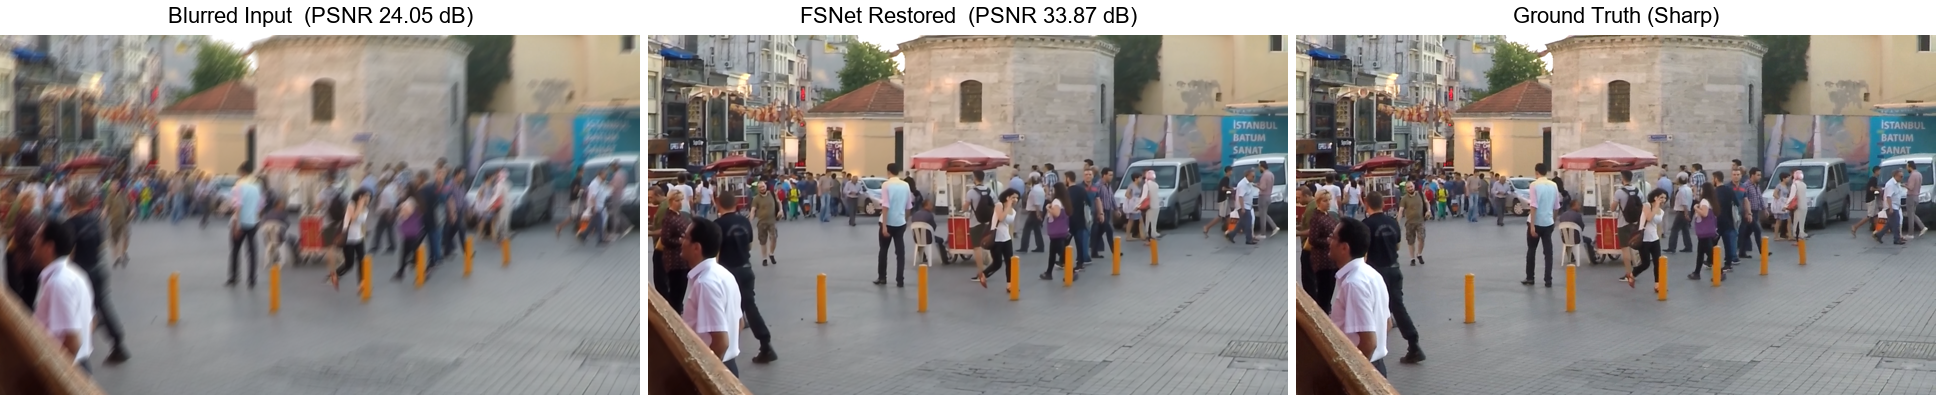

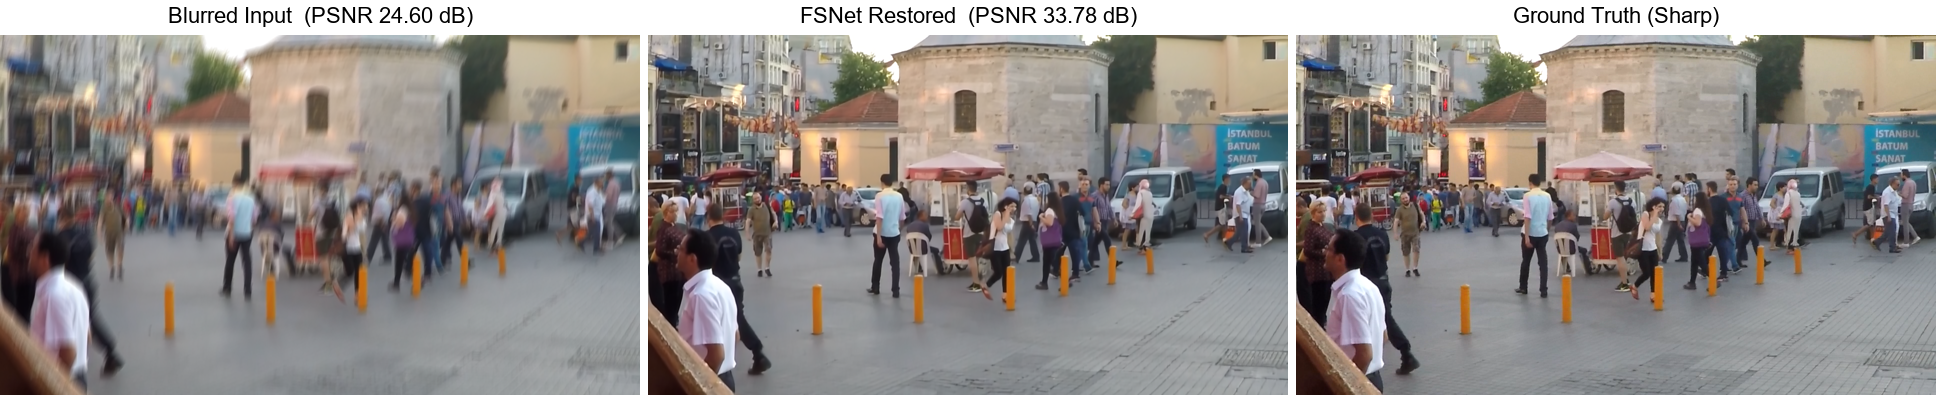

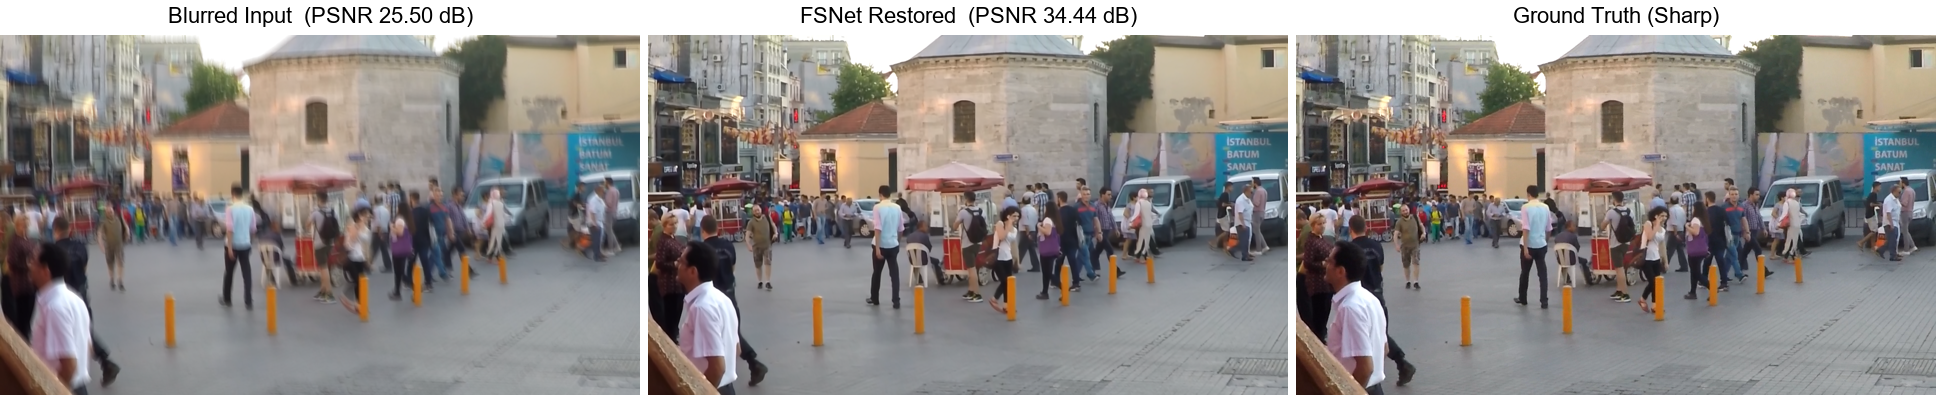

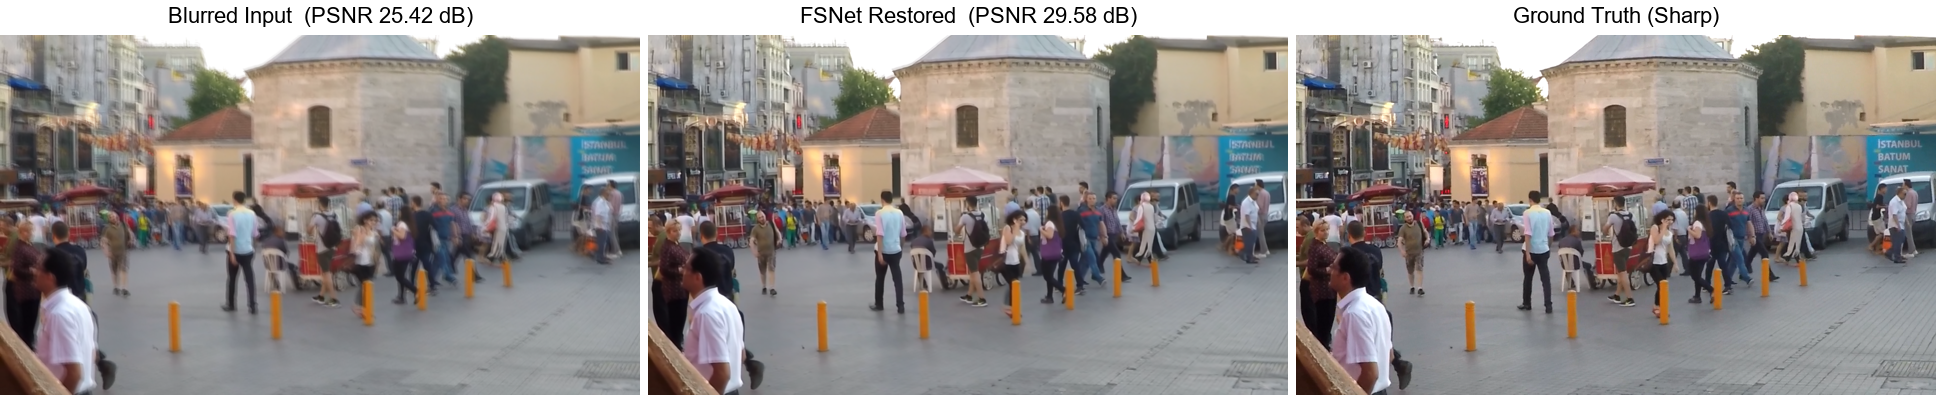

In [25]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as IPImage, display

try:
    from skimage.metrics import peak_signal_noise_ratio
except Exception:
    def peak_signal_noise_ratio(a, b, data_range=255):
        a = np.asarray(a, dtype=np.float64); b = np.asarray(b, dtype=np.float64)
        mse = np.mean((a - b) ** 2)
        return float("inf") if mse == 0 else 10 * np.log10((data_range ** 2) / mse)

def load_font(size):
    for p in (r"C:\Windows\Fonts\arial.ttf", "arial.ttf", "DejaVuSans.ttf"):
        try:
            return ImageFont.truetype(p, size)
        except (OSError, IOError):
            continue
    return ImageFont.load_default()

def _psnr(a_img, b_img):
    return peak_signal_noise_ratio(np.asarray(a_img, np.float32),
                                   np.asarray(b_img, np.float32), data_range=255)

def make_panel(img, label, pw, ph, hh, font):
    img = img.resize((pw, ph), Image.BICUBIC)
    canvas = Image.new("RGB", (pw, ph + hh), (255, 255, 255))
    canvas.paste(img, (0, hh))
    d = ImageDraw.Draw(canvas)
    bbox = d.textbbox((0, 0), label, font=font)
    tw = bbox[2] - bbox[0]
    d.text(((pw - tw) / 2, (hh - (bbox[3] - bbox[1])) / 2 - bbox[1]), label, fill=(0, 0, 0), font=font)
    return canvas

def build_comparison(blur, restored, gt, scale=0.5, gap=8):
    w, h = gt.size
    pw, ph = int(w * scale), int(h * scale)
    hh = max(24, int(44 * scale * 1.6))
    font = load_font(max(14, int(28 * scale * 1.6)))
    pb = _psnr(blur.resize(gt.size), gt)
    pr = _psnr(restored.resize(gt.size), gt)
    panels = [
        make_panel(blur,     f"Blurred Input  (PSNR {pb:.2f} dB)",  pw, ph, hh, font),
        make_panel(restored, f"FSNet Restored  (PSNR {pr:.2f} dB)", pw, ph, hh, font),
        make_panel(gt,       "Ground Truth (Sharp)",                pw, ph, hh, font),
    ]
    out = Image.new("RGB", (pw * 3 + gap * 2, ph + hh), (255, 255, 255))
    for i, p in enumerate(panels):
        out.paste(p, (i * (pw + gap), 0))
    return out, pb, pr

blur_dir = DATA_DIR / "valid" / "blur"
gt_dir   = DATA_DIR / "valid" / "sharp"
names = sorted(p.name for p in RESULT_DIR.glob("*.png"))
print(f"共 {len(names)} 张恢复图, 生成对比图到 {COMPARE_DIR}")

for name in names:
    bp, rp, gp = blur_dir / name, RESULT_DIR / name, gt_dir / name
    if not (bp.exists() and rp.exists() and gp.exists()):
        print("[跳过] 缺文件:", name); continue
    blur = Image.open(bp).convert("RGB")
    rest = Image.open(rp).convert("RGB")
    gt   = Image.open(gp).convert("RGB")
    comp, pb, pr = build_comparison(blur, rest, gt)
    comp.save(COMPARE_DIR / f"compare_{name}")
    print(f"  {name}: 模糊 {pb:.2f} -> 恢复 {pr:.2f} dB  (+{pr - pb:.2f})")

# 内联显示前 4 张
for name in names[:4]:
    display(IPImage(str(COMPARE_DIR / f"compare_{name}")))

## 8.1 定性可视化：恢复细节、残差热力图与频域复原

在马卡龙风格下并排展示 **模糊 / FSNet 恢复 / 清晰原图**，并叠加：
- **残差热力图** |恢复 − GT|，越亮代表残差越大（恢复越不准）；
- **频域复原对比曲线**，展示 FSNet 把模糊图丢失的高频补了回来——这正是其「频率选择 + FFT 损失」设计的直接体现。

默认挑选 PSNR 提升最大的样本进行展示。

In [ ]:
# ========== 定性可视化：三栏对比 + 残差热力图 + 频域复原 ==========
from PIL import Image

_blur_dir = DATA_DIR / "valid" / "blur"
_gt_dir = DATA_DIR / "valid" / "sharp"
_rest_dir = RESULT_DIR

_avail = sorted(p.name for p in _rest_dir.glob("*.png"))
if not _avail:
    print("results/test 下没有恢复图，请先运行第 7 节推理。")
else:
    # 默认挑选 PSNR 提升最大的样本; 否则取前两张
    pick = _avail[:2]
    if "EVAL_RESULTS" in globals() and EVAL_RESULTS:
        _avail_set = set(_avail)
        _gain = np.array(EVAL_RESULTS["psnr_restored"]) - np.array(EVAL_RESULTS["psnr_blur"])
        _order = np.argsort(_gain)[::-1]
        _ranked = [EVAL_RESULTS["name"][i] for i in _order if EVAL_RESULTS["name"][i] in _avail_set]
        if _ranked:
            pick = _ranked[:2]

    def _to_gray(img):
        return np.asarray(img.convert("RGB"), np.float32) @ np.array([0.299, 0.587, 0.114], np.float32)

    def _logspec(g):
        return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(g))))

    def _radial(spec):
        h, w = spec.shape
        cy, cx = h // 2, w // 2
        yy, xx = np.indices((h, w))
        r = np.hypot(xx - cx, yy - cy).astype(int)
        return np.bincount(r.ravel(), spec.ravel()) / np.maximum(np.bincount(r.ravel()), 1)

    for name in pick:
        rest = Image.open(_rest_dir / name).convert("RGB")
        blur = Image.open(_blur_dir / name).convert("RGB").resize(rest.size)
        gt = Image.open(_gt_dir / name).convert("RGB").resize(rest.size)

        ra = np.asarray(rest, np.float32)
        ga = np.asarray(gt, np.float32)
        resid = np.abs(ra - ga).mean(axis=2)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes[0].imshow(blur); axes[0].set_title("模糊输入 Blurred"); axes[0].axis("off")
        axes[1].imshow(rest); axes[1].set_title("FSNet 恢复 Restored"); axes[1].axis("off")
        axes[2].imshow(gt);   axes[2].set_title("清晰原图 GT"); axes[2].axis("off")
        im = axes[3].imshow(resid, cmap="makaron")
        axes[3].set_title("残差 |恢复-GT| (均值 %.2f)" % resid.mean()); axes[3].axis("off")
        fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
        fig.suptitle("样本 %s" % name, fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(VIZ_DIR / ("05_qual_" + name), bbox_inches="tight")
        plt.show()

        # 频域复原对比曲线
        rb = _radial(_logspec(_to_gray(blur)))
        rr = _radial(_logspec(_to_gray(rest)))
        rg = _radial(_logspec(_to_gray(gt)))
        freq = np.linspace(0, 1, len(rb))
        plt.figure(figsize=(9, 4.5))
        plt.plot(freq, rb, color=mk(0.85), linewidth=2, label="模糊 Blurred")
        plt.plot(freq, rr, color=mk(0.5), linewidth=2, label="FSNet 恢复")
        plt.plot(freq, rg, color=mk(0.12), linewidth=2.2, label="清晰 GT")
        plt.xlabel("归一化空间频率"); plt.ylabel("平均对数幅值")
        plt.title("频域复原对比 — %s" % name)
        plt.legend()
        plt.tight_layout()
        plt.savefig(VIZ_DIR / ("06_freq_" + name), bbox_inches="tight")
        plt.show()